# Logistic Regression Uplift Baseline

This notebook implements a simple T-learner baseline with logistic regression: one model for the control outcome and one model for the treated outcome. Predicted uplift is the difference between the two predicted visit probabilities.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
RANDOM_STATE = 42

In [3]:
data_path = Path("../data/raw/hillstrom_email.csv")
df = pd.read_csv(data_path)

print(f"Loaded {data_path.name} with shape {df.shape}")
df.head()

Loaded hillstrom_email.csv with shape (64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [4]:
numerical_columns = ["recency", "history", "mens", "womens"]
categorical_columns = ["history_segment", "zip_code", "newbie", "channel"]
feature_columns = numerical_columns + categorical_columns
treatment_column = "treatment"
outcome_column = "visit"

df[treatment_column] = (df["segment"] != "No E-Mail").astype(int)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[treatment_column],
)

train_df = train_df.copy()
test_df = test_df.copy()

print("Training rows:", len(train_df))
print("Testing rows: ", len(test_df))

Training rows: 51200
Testing rows:  12800


In [5]:
split_summary = []
for split_name, split_df in [("train", train_df), ("test", test_df)]:
    grouped = (
        split_df.groupby(treatment_column)[outcome_column]
        .agg(["size", "mean"])
        .reset_index()
    )
    grouped["split"] = split_name
    grouped["group"] = grouped[treatment_column].map({0: "No E-Mail", 1: "Any E-Mail"})
    grouped = grouped.rename(columns={"size": "customers", "mean": "visit_rate"})
    split_summary.append(grouped[["split", "group", "customers", "visit_rate"]])

pd.concat(split_summary, ignore_index=True)

,split,group,customers,visit_rate
0,train,No E-Mail,17045,0.105837
1,train,Any E-Mail,34155,0.166916
2,test,No E-Mail,4261,0.107487
3,test,Any E-Mail,8539,0.167584


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_columns,
        ),
    ]
)

X_train_processed = preprocessor.fit_transform(train_df[feature_columns])
X_test_processed = preprocessor.transform(test_df[feature_columns])

train_treatment = train_df[treatment_column].to_numpy()
train_outcome = train_df[outcome_column].to_numpy()

control_mask = train_treatment == 0
treatment_mask = train_treatment == 1

control_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
treatment_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

print("Shared training matrix:", X_train_processed.shape)
print("Shared testing matrix :", X_test_processed.shape)
print("Control training rows:", int(control_mask.sum()))
print("Treatment training rows:", int(treatment_mask.sum()))

Shared training matrix: (51200, 19)
Shared testing matrix : (12800, 19)
Control training rows: 17045
Treatment training rows: 34155


In [7]:
control_model.fit(X_train_processed[control_mask], train_outcome[control_mask])
treatment_model.fit(X_train_processed[treatment_mask], train_outcome[treatment_mask])

LogisticRegression(max_iter=1000, random_state=42)

In [8]:
pred_control = control_model.predict_proba(X_test_processed)[:, 1]
pred_treatment = treatment_model.predict_proba(X_test_processed)[:, 1]

test_treatment = test_df[treatment_column].to_numpy()
test_outcome = test_df[outcome_column].to_numpy()

factual_probability = np.where(test_treatment == 1, pred_treatment, pred_control)

results = test_df.reset_index(drop=True).copy()
results["pred_control"] = pred_control
results["pred_treatment"] = pred_treatment
results["predicted_uplift"] = results["pred_treatment"] - results["pred_control"]
results["factual_probability"] = factual_probability

results.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment,pred_control,pred_treatment,predicted_uplift,factual_probability
0,6,5) $500 - $750,508.62,0,1,Surburban,1,Web,Mens E-Mail,1,0,0.0,1,0.084109,0.183911,0.099802,0.183911
1,10,4) $350 - $500,460.26,1,1,Urban,0,Phone,Womens E-Mail,0,0,0.0,1,0.133941,0.238619,0.104678,0.238619
2,10,1) $0 - $100,35.05,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0,1,0.074116,0.118201,0.044085,0.118201
3,7,2) $100 - $200,141.74,1,0,Urban,0,Phone,Mens E-Mail,0,0,0.0,1,0.084800,0.129277,0.044477,0.129277
4,7,1) $0 - $100,31.30,0,1,Rural,1,Phone,Mens E-Mail,0,0,0.0,1,0.064631,0.134576,0.069945,0.134576


## Factual Prediction Metrics

In [9]:
pd.DataFrame(
    {
        "test_log_loss": [log_loss(test_outcome, np.clip(factual_probability, 1e-6, 1 - 1e-6))],
        "test_roc_auc": [roc_auc_score(test_outcome, factual_probability)],
        "test_brier_score": [np.mean((test_outcome - factual_probability) ** 2)],
    }
)

,test_log_loss,test_roc_auc,test_brier_score
0,0.400856,0.644256,0.121401


In [10]:
control_rate = results.loc[results[treatment_column] == 0, outcome_column].mean()
treatment_rate = results.loc[results[treatment_column] == 1, outcome_column].mean()
randomized_test_ate = treatment_rate - control_rate

pd.DataFrame(
    {
        "randomized_test_ATE": [randomized_test_ate],
        "average_predicted_uplift": [results["predicted_uplift"].mean()],
        "median_predicted_uplift": [results["predicted_uplift"].median()],
        "minimum_predicted_uplift": [results["predicted_uplift"].min()],
        "maximum_predicted_uplift": [results["predicted_uplift"].max()],
    }
)

,randomized_test_ATE,average_predicted_uplift,median_predicted_uplift,minimum_predicted_uplift,maximum_predicted_uplift
0,0.060098,0.061406,0.063158,-0.020389,0.143348


## Uplift Evaluation

Rank the randomized test set by predicted uplift and estimate cumulative incremental visits with inverse-propensity weighting, matching the evaluation pattern used in the TARNet notebook.

In [11]:
def uplift_curve(frame):
    ranked = frame.sort_values("predicted_uplift", ascending=False).reset_index(drop=True)

    treated = ranked[treatment_column].to_numpy(dtype=float)
    outcome = ranked[outcome_column].to_numpy(dtype=float)
    propensity = treated.mean()

    contribution = outcome * (
        treated / propensity - (1 - treated) / (1 - propensity)
    )
    cumulative_gain = np.concatenate([[0.0], np.cumsum(contribution) / len(ranked)])
    fraction_targeted = np.linspace(0, 1, len(cumulative_gain))
    random_gain = fraction_targeted * cumulative_gain[-1]

    return {
        "ranked": ranked,
        "contribution": contribution,
        "fraction_targeted": fraction_targeted,
        "cumulative_gain": cumulative_gain,
        "random_gain": random_gain,
        "AUUC": np.trapz(cumulative_gain, fraction_targeted),
        "Qini_coefficient": np.trapz(cumulative_gain - random_gain, fraction_targeted),
    }


curve_results = uplift_curve(results)

pd.DataFrame(
    {
        "AUUC": [curve_results["AUUC"]],
        "Qini_coefficient": [curve_results["Qini_coefficient"]],
    }
)

,AUUC,Qini_coefficient
0,0.035656,0.005608


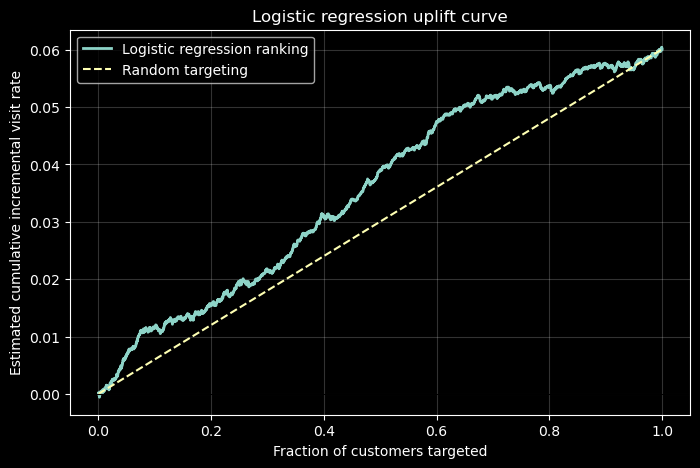

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    curve_results["fraction_targeted"],
    curve_results["cumulative_gain"],
    label="Logistic regression ranking",
    linewidth=2,
)
plt.plot(
    curve_results["fraction_targeted"],
    curve_results["random_gain"],
    label="Random targeting",
    linestyle="--",
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Fraction of customers targeted")
plt.ylabel("Estimated cumulative incremental visit rate")
plt.title("Logistic regression uplift curve")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [13]:
targeting_rows = []
contribution = curve_results["contribution"]

for fraction in [0.05, 0.10, 0.20]:
    number_targeted = int(np.ceil(len(contribution) * fraction))
    estimated_uplift = contribution[:number_targeted].mean()
    targeting_rows.append(
        {
            "target_fraction": fraction,
            "customers_in_evaluation": number_targeted,
            "estimated_visit_uplift": estimated_uplift,
            "incremental_visits_per_1000": 1000 * estimated_uplift,
        }
    )

pd.DataFrame(targeting_rows)

,target_fraction,customers_in_evaluation,estimated_visit_uplift,incremental_visits_per_1000
0,0.05,640,0.135511,135.510884
1,0.10,1280,0.115630,115.630263
2,0.20,2560,0.076979,76.979379
